# Opdracht - 


## Inlezen van de variabelen - creëren van de omgeving

In [24]:
import os
import json
import sys
import pandas as pd
from datetime import date, datetime
import calendar
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "figure.facecolor":    "white",
    "axes.facecolor":      "#F8F9FA",
    "axes.grid":           True,
    "axes.spines.top":     False,
    "axes.spines.right":   False,
    "axes.titlesize":      14,
    "axes.titleweight":    "bold",
    "axes.labelsize":      13,
    "axes.labelcolor":     "#333333",
    "xtick.labelsize":     12,
    "ytick.labelsize":     12,
    "xtick.color":         "#555555",
    "ytick.color":         "#555555",
    "grid.color":          "white",
    "grid.linewidth":      1.2,
    "lines.linewidth":     1.5,
    "legend.fontsize":     10,
    "font.family":         "Arial"
})

os.chdir(r"C:\Users\kurtm\Documents\Oefening01.01")



# Lees de configuratie in
config = load_project_config(r"./config.json")




## Main programma - lees de broninformatie in

In [ ]:



#Overloop alle files in de Source directory
SourceDir = os.path.join(config["Directories"]["Root"],config["Directories"]["Data"],config["Directories"]["Input"])

df_births = pd.DataFrame()

for ReadFile in os.listdir(SourceDir):
    # lees de file in
    if  not ReadFile.endswith('.csv'):
        continue
    EchteGeboortedag = os.path.splitext(ReadFile)[0] 
    #bepaal of geldige datum in filenaam - check dan in de config wat je moet doen
    if not is_geldige_datum(EchteGeboortedag):
        functie_naam = config["Decisions"]["Wrong Date"]
        if not functie_naam in globals() or callable(globals()[functie_naam]):
            continue
        EchteGeboortedag = globals()[functie_naam](EchteGeboortedag)


    df_File = pd.read_csv(os.path.join(SourceDir,ReadFile))
    df_File['verwachte datum'] = pd.to_datetime(df_File['verwachte datum'])
    df_File["date"] = pd.to_datetime(EchteGeboortedag)
    df_File["SourceFile"] = ReadFile
    df_births = pd.concat([df_births, df_File], ignore_index=True)

df_births = df_births.sort_values('date')
df_births["dag van het jaar"] = df_births["date"].dt.dayofyear
df_births["dag van de week"] = df_births["date"].dt.dayofweek
df_births.to_excel(os.path.join(config["Directories"]["Root"],config["Directories"]["Data"],config["Directories"]["Temp"],config["Files"]["RestFile"]), index=False)


# Main programma - voer oefeningen uit

## Stap 1: data inlezen (1 pnt)

Bouw één DataFrame `df_births` met alle geboortes uit de map `data/geboortes`.

**Output**
- `df_births` bevat alle rijen uit alle CSV-bestanden.
- `df_births` bevat een kolom `date` als echte datetime (`YYYY-MM-DD`), afgeleid uit de bestandsnaam.
- `df_births` bevat een kolom `dag_van_jaar` met waarden van 1 tot 365.
- De observatie-grain is identiek aan de bron: **1 rij = 1 geboorte**.

**Te tonen checks**
- Aantal rijen in `df_births`
- Minimum- en maximumdatum
- Minimum en maximum van `day_of_year`
- Geen onbestaande datums (bv. dag 0, dag 32, 29/2 in niet-schrikkeljaren, geboortejaar 2027,...)

In [11]:
df_births.dtypes

gemeente                       str
naam                           str
geslacht                       str
verwachte datum     datetime64[us]
date                datetime64[us]
SourceFile                     str
dag van het jaar             int32
dag van de week              int32
dtype: object

In [12]:
len(df_births)

116850

In [ ]:
df_births["date"].min()

Timestamp('2019-12-31 00:00:00')

In [14]:
df_births["date"].max()

Timestamp('2019-12-31 00:00:00')

In [16]:
df_births["dag van het jaar"].min()

np.int32(1)

In [17]:
df_births["dag van het jaar"].max()

np.int32(365)

# geen onbestaande datums
Werd opgelost et een functie die in de config werd vermeld
1. eerstvolgende
2. Vorige
3. ignore als geen geldige functie

## Stap 2: EDA

### Vraag 1: Initial Plot

Maak een plot van het aantal geboortes per dag van het jaar. Gebruik een horizontale rode stippellijn om het gemiddelde aan te geven. (1 pnt)

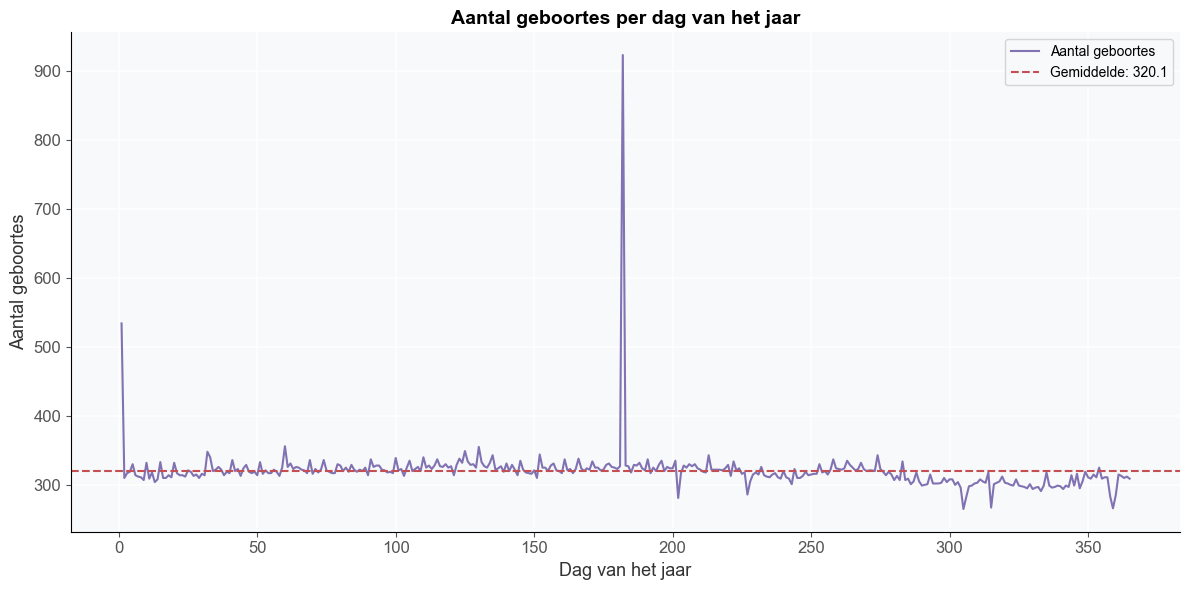

In [26]:
kleuren = config["Plot"]["kleuren"]

geboortes_per_dag = df_births.groupby("dag van het jaar").size().reset_index(name="aantal_geboortes")
gemiddelde = geboortes_per_dag["aantal_geboortes"].mean()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(
    geboortes_per_dag["dag van het jaar"],
    geboortes_per_dag["aantal_geboortes"],
    color=kleuren["paars"],
    label="Aantal geboortes"
)
ax.axhline(
    gemiddelde,
    color=kleuren["rood"],
    linestyle="--",
    label=f"Gemiddelde: {gemiddelde:.1f}"
)
ax.set_title("Aantal geboortes per dag van het jaar")
ax.set_xlabel("Dag van het jaar")
ax.set_ylabel("Aantal geboortes")
ax.legend()
plt.tight_layout()
plt.show()

### Vraag 2: Outliers vinden & behandelen
#### Vraag 2.1 Zoek alle outliers in de dataset. (1 pnt)

Kies een regel om een datapunt als 'outlier' te classifieren, pas deze toe en verdedig je keuze.

In [41]:
MaxLow

862

In [52]:
maximum = geboortes_per_dag["aantal_geboortes"].max()
minimum = geboortes_per_dag["aantal_geboortes"].min()



x = 80

# bepaal de ondergrens voor de maxima
MaxLow = int(maximum - ((maximum - gemiddelde) *x/100))

# bepaal de bovengrens voor de minima
MinHigh = int(minimum + ((gemiddelde - minimum) *x/100))

df_MaxOutlier = geboortes_per_dag.loc[geboortes_per_dag["aantal_geboortes"] > MaxLow]
df_MinOutlier = geboortes_per_dag.loc[geboortes_per_dag["aantal_geboortes"] < MinHigh]
display(df_MaxOutlier)
display(df_MinOutlier)

,dag van het jaar,aantal_geboortes
0,1,534
181,182,923


,dag van het jaar,aantal_geboortes
8,9,307
12,13,304
13,14,308
201,202,281
226,227,286
...,...,...
346,347,295
347,348,305
357,358,283
358,359,266


60

#### Vraag 2.2 Outlier remediation (1 pnt)
Je stelt vast dat twee dagen eruit springen als outliers. Corrigeer en voeg foute rijen toe aan `df_wrong` met een duidelijk omschreven reden. Documenteer in een comment welk patroon je opmerkte en  verdedig je correctiestrategie. Hermaak ten slotte de figuur uit Vraag 1 op basis van `df_births_clean`.

# Functies

In [2]:
def is_geldige_datum(datum: str) -> bool:
    try:
        datetime.strptime(datum, '%Y-%m-%d')
        return True
    except ValueError:
        return False

def volgende_geldige_datum(datum: str) -> str:
    jaar, maand, dag = map(int, datum.split('-'))
    try:
        return date(jaar, maand, dag).strftime('%Y-%m-%d')
    except ValueError:
        if maand == 12:
            maand = 1
            jaar += 1
        else:
            maand += 1
        return date(jaar, maand, 1).strftime('%Y-%m-%d')

def laatste_geldige_datum(datum: str) -> str:
    jaar, maand, dag = map(int, datum.split('-'))
    laatste_dag = calendar.monthrange(jaar, maand)[1]
    geldige_dag = min(dag, laatste_dag)
    return date(jaar, maand, geldige_dag).strftime('%Y-%m-%d')

In [8]:
# inlezen configfile

def load_project_config(config_path):
    """
    Laadt de project-configuratie uit een JSON-bestand.
    Stopt het programma met een duidelijke foutmelding als er iets mis is.
    
    Returns:
        dict: de geladen configuratie
        
    Exits:
        sys.exit(1) bij file not found
        sys.exit(2) bij ongeldige JSON
        sys.exit(3) bij onverwachte andere fouten
    """
    # Zorg dat we een absoluut pad hebben (veiliger in notebooks/scripts)
    config_file = os.path.abspath(config_path)

    # 1. Bestaat het bestand überhaupt?
    if not os.path.isfile(config_file):
        print("FOUT: Configuratiebestand niet gevonden", file=sys.stderr)
        print(f"   Pad: {config_file}", file=sys.stderr)
        print("   Verwacht: JSON-bestand met 'directories' sleutel", file=sys.stderr)
        sys.exit(1)

    # 2. Proberen in te lezen
    try:
        with open(config_file, "r", encoding="utf-8") as f:
            config = json.load(f)

    except json.JSONDecodeError as e:
        print("FOUT: Ongeldige JSON syntax in configuratiebestand", file=sys.stderr)
        print(f"Bestand  : {config_file}", file=sys.stderr)
        print(f"Regel    : {e.lineno}", file=sys.stderr)
        print(f"Positie  : {e.colno}", file=sys.stderr)
        print(f"Boodschap: {e.msg}", file=sys.stderr)
        sys.exit(2)

    except Exception as e:
        print("FOUT: Kan configuratiebestand niet lezen", file=sys.stderr)
        print(f"Bestand : {config_file}", file=sys.stderr)
        print(f"Fout    : {type(e).__name__}", file=sys.stderr)
        print(f"Bericht : {e}", file=sys.stderr)
        sys.exit(3)

    # 3. Minimale inhoudscontrole
    if not isinstance(config, dict):
        print("FOUT: Configuratie moet een JSON object (dictionary) zijn", file=sys.stderr)
        sys.exit(4)

    if "Directories" not in config:
        print("FOUT: Verplichte sleutel 'Directories' ontbreekt in configuratie", file=sys.stderr)
        sys.exit(5)

    if not isinstance(config["Directories"], dict):
        print("FOUT: 'Directories' moet een object (dictionary) zijn", file=sys.stderr)
        sys.exit(6)

    

    # Alles ok → geef config terug
    return config